# 05. Pre-modeling EDA -- disability strand



## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_theme(style='whitegrid')
DATA_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\data\processed")
FIGURE_DIR = Path(r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_figures")
FIGURE_DIR.mkdir(parents=True, exist_ok=True)


In [2]:
dis_level = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_all_years.csv')
dis_overall = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_overall_all_years.csv')
dis_dm = pd.read_csv(DATA_DIR / 'RQ3_borough_disability_days_months_all_years.csv')

dis_level['small_cell'] = dis_level['n'] < 30
print('rows:', {'dis_level': len(dis_level), 'dis_overall': len(dis_overall), 'dis_dm': len(dis_dm)})
print('overall small-cell rate:', dis_level['small_cell'].mean().round(3))


rows: {'dis_level': 514048, 'dis_overall': 4096, 'dis_dm': 511488}
overall small-cell rate: 0.695


## 1. Sample size structure


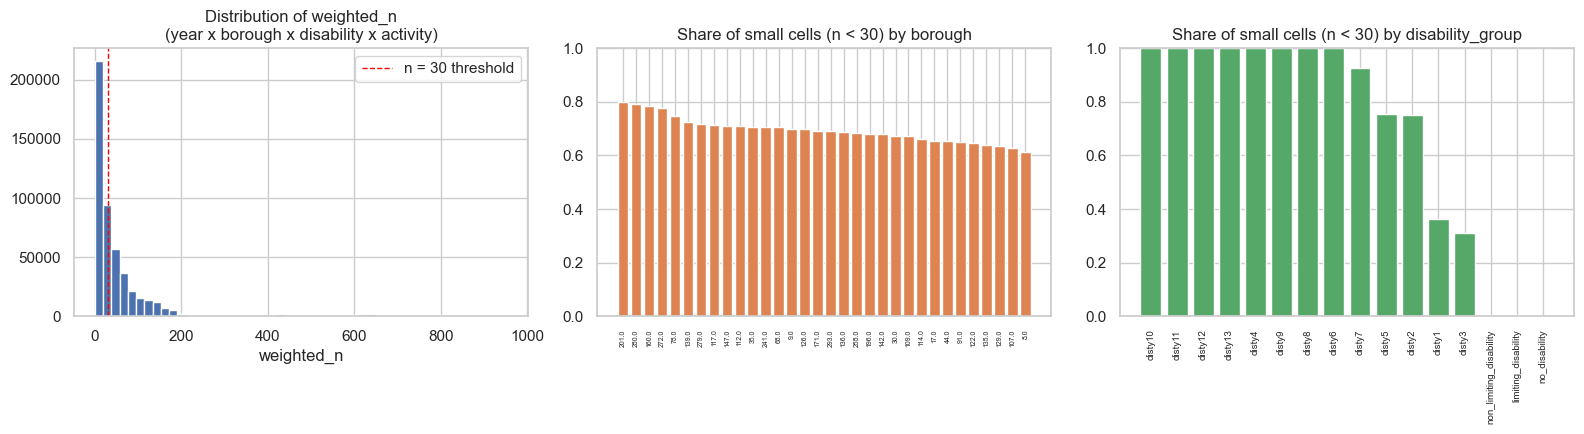

Overall small-cell rate: 69.5%
Boroughs with the highest small-cell rate:
LA_2023
201.0    0.800921
280.0    0.792082
160.0    0.783242
272.0    0.777639
78.0     0.745393
Name: small_cell, dtype: float64
Disability groups with the highest small-cell rate:
disability_group
disty10    1.0
disty11    1.0
disty12    1.0
disty13    1.0
disty4     1.0
Name: small_cell, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

axes[0].hist(dis_level['weighted_n'].dropna(), bins=50, color='#4C72B0')
axes[0].set_title('Distribution of weighted_n\n(year x borough x disability x activity)')
axes[0].set_xlabel('weighted_n')
axes[0].axvline(30, color='red', linestyle='--', linewidth=1, label='n = 30 threshold')
axes[0].legend()

by_borough = dis_level.groupby('LA_2023')['small_cell'].mean().sort_values(ascending=False)
axes[1].bar(by_borough.index.astype(str), by_borough.values, color='#DD8452')
axes[1].set_title('Share of small cells (n < 30) by borough')
axes[1].tick_params(axis='x', labelrotation=90, labelsize=5)
axes[1].set_ylim(0, 1)

by_group = dis_level.groupby('disability_group')['small_cell'].mean().sort_values(ascending=False)
axes[2].bar(by_group.index.astype(str), by_group.values, color='#55A868')
axes[2].set_title('Share of small cells (n < 30) by disability_group')
axes[2].tick_params(axis='x', labelrotation=90, labelsize=7)
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_01_sample_size_structure.png', dpi=150)
plt.show()

print(f"Overall small-cell rate: {dis_level['small_cell'].mean():.1%}")
print('Boroughs with the highest small-cell rate:')
print(by_borough.head(5))
print('Disability groups with the highest small-cell rate:')
print(by_group.head(5))


## 2. Temporal structure and how predictable the trend actually is


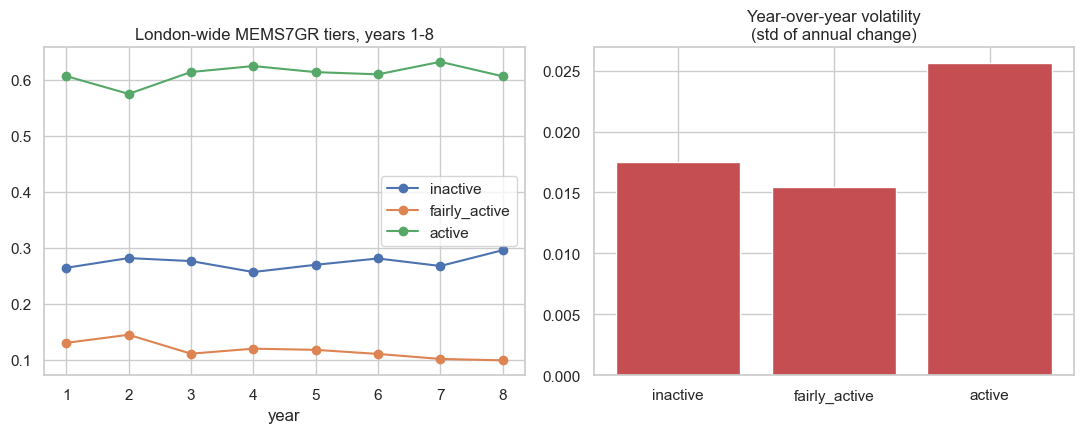

Year-over-year volatility:
inactive         0.0175
fairly_active    0.0155
active           0.0257
dtype: float64


In [10]:
valid_overall = dis_overall.dropna(
    subset=['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']
).query('weighted_n > 0')

london_trend = (
    valid_overall.groupby('year')[['inactive_rate', 'fairly_active_rate', 'active_rate', 'weighted_n']]
    .apply(lambda g: pd.Series({
        'inactive': np.average(g['inactive_rate'], weights=g['weighted_n']),
        'fairly_active': np.average(g['fairly_active_rate'], weights=g['weighted_n']),
        'active': np.average(g['active_rate'], weights=g['weighted_n']),
    }))
    .reset_index()
)

year_over_year_change = london_trend[['inactive', 'fairly_active', 'active']].diff().dropna()
volatility = year_over_year_change.std()

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for column in ['inactive', 'fairly_active', 'active']:
    axes[0].plot(london_trend['year'], london_trend[column], marker='o', label=column)
axes[0].set_title('London-wide MEMS7GR tiers, years 1-8')
axes[0].set_xlabel('year')
axes[0].legend()

axes[1].bar(volatility.index, volatility.values, color='#C44E52')
axes[1].set_title('Year-over-year volatility\n(std of annual change)')

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_02_trend_and_volatility.png', dpi=150)
plt.show()

print('Year-over-year volatility:')
print(volatility.round(4))


## 3. Activity participation concentration

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_26420\493892901.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))


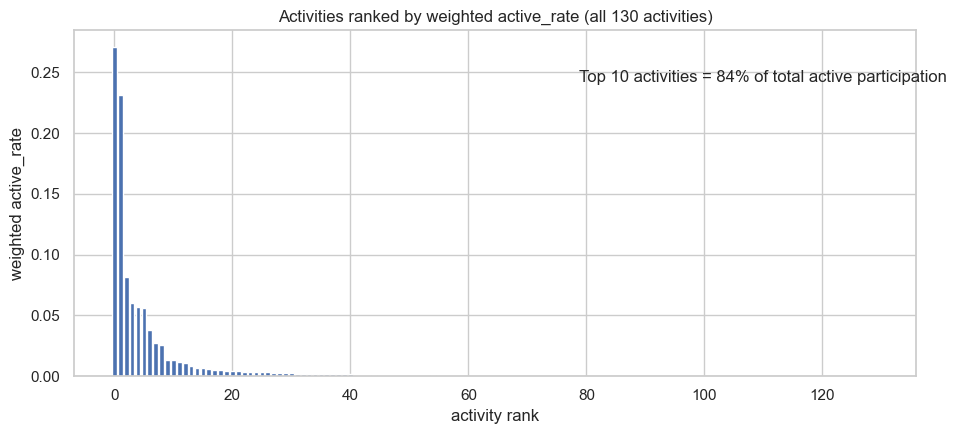

Top 10 activities:
activity
ACTTRAV_C03       0.270924
WALKTRAV_B02      0.230992
GARD_B08          0.082002
RUNJOG_U07        0.060543
CYC_OLD_M02       0.056802
CYCTRAV_B04       0.055964
CYCLEISURE_N01    0.038265
FOOTBALL_F01      0.026994
DANCEOTHER_O01    0.025794
DANCEART_B05      0.013435
dtype: float64


In [5]:
activity_participation = (
    dis_level.dropna(subset=['active_rate', 'weighted_n'])
    .query('weighted_n > 0')
    .groupby('activity')
    .apply(lambda g: np.average(g['active_rate'], weights=g['weighted_n']))
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar(range(len(activity_participation)), activity_participation.values, color='#4C72B0')
ax.set_title('Activities ranked by weighted active_rate (all 130 activities)')
ax.set_xlabel('activity rank')
ax.set_ylabel('weighted active_rate')

top10_share = activity_participation.head(10).sum() / activity_participation.sum()
ax.text(0.6, 0.85, f'Top 10 activities = {top10_share:.0%} of total active participation',
        transform=ax.transAxes)

plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_03_activity_concentration.png', dpi=150)
plt.show()

print('Top 10 activities:')
print(activity_participation.head(10))


## 4. Disability sub-type co-occurrence (needs the raw individual-level files)


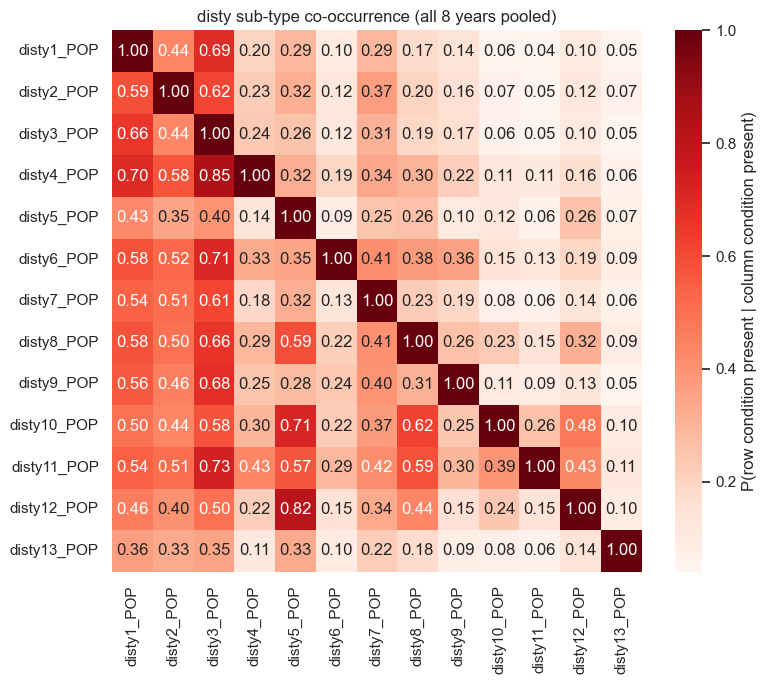

In [7]:
import os

root = r"C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20"
year_files = {
    1: os.path.join(root, "Yifeng Mao", "data", "active_lives_1516_london_125.csv"),
    2: os.path.join(root, "Yifeng Mao", "data", "active_lives_1617_london_125.csv"),
    3: os.path.join(root, "Siyan Xin", "2017~2018", "2017_data_125_activities.csv"),
    4: os.path.join(root, "Siyan Xin", "2018~2019", "2018_data_125_activities.csv"),
    5: os.path.join(root, "Shuhan Zhao", "docs", "1920_london32_stable125.csv"),
    6: os.path.join(root, "Shuhan Zhao", "docs", "2021_london32_stable125.csv"),
    7: os.path.join(root, "Jingyi Hua", "data", "processed", "year7_125activities.csv"),
    8: os.path.join(root, "Jingyi Hua", "data", "processed", "year8_125activities.csv"),
}

disty_cols = [f'disty{i}_POP' for i in range(1, 14)]

co_occurrence_frames = []
for year_number, file_path in year_files.items():
    header = pd.read_csv(file_path, nrows=0).columns
    col_lookup = {c.lower(): c for c in header}
    age_col = col_lookup.get('age16plus')
    if age_col is None:
        raise KeyError(f"Year {year_number} has no Age16plus-like column, check {file_path}")

    year_df = pd.read_csv(file_path, usecols=disty_cols + [age_col])
    year_df = year_df.rename(columns={age_col: 'Age16plus'})
    year_df = year_df[year_df['Age16plus'] == 1]
    co_occurrence_frames.append(year_df[disty_cols])

all_disty = pd.concat(co_occurrence_frames, ignore_index=True)
co_occurrence = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)
for a in disty_cols:
    has_a = all_disty[a] == 1
    for b in disty_cols:
        co_occurrence.loc[a, b] = (all_disty.loc[has_a, b] == 1).mean() if has_a.sum() > 0 else np.nan

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(co_occurrence.astype(float), annot=True, fmt='.2f', cmap='Reds', ax=ax,
            cbar_kws={'label': 'P(row condition present | column condition present)'})
ax.set_title('disty sub-type co-occurrence (all 8 years pooled)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_04_disty_co_occurrence.png', dpi=150)
plt.show()


## 5. How the three outcome measures relate to each other



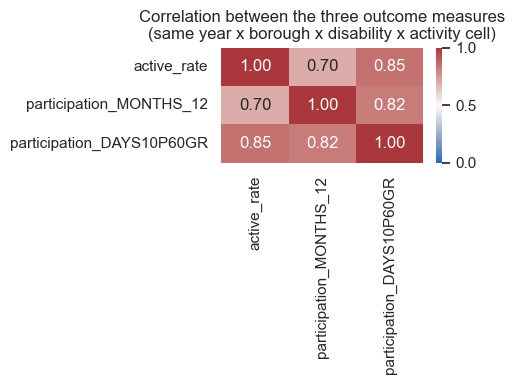

                           active_rate  participation_MONTHS_12  \
active_rate                      1.000                    0.699   
participation_MONTHS_12          0.699                    1.000   
participation_DAYS10P60GR        0.849                    0.821   

                           participation_DAYS10P60GR  
active_rate                                    0.849  
participation_MONTHS_12                        0.821  
participation_DAYS10P60GR                      1.000  


In [8]:
merged_targets = dis_level.merge(
    dis_dm, on=['year', 'LA_2023', 'disability_group', 'activity'], how='inner'
)

correlation_matrix = merged_targets[
    ['active_rate', 'participation_MONTHS_12', 'participation_DAYS10P60GR']
].corr()

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='vlag', vmin=0, vmax=1, ax=ax)
ax.set_title('Correlation between the three outcome measures\n(same year x borough x disability x activity cell)')
plt.tight_layout()
plt.savefig(FIGURE_DIR / 'figure_05_outcome_correlation.png', dpi=150)
plt.show()

print(correlation_matrix.round(3))


## 6. Summary tables


In [9]:
summary_tables_dir = FIGURE_DIR.parent / 'pre_eda_tables'
summary_tables_dir.mkdir(parents=True, exist_ok=True)

by_borough.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_borough.csv')
by_group.rename('small_cell_rate').to_csv(summary_tables_dir / 'small_cell_rate_by_disability_group.csv')
london_trend.to_csv(summary_tables_dir / 'london_trend_by_year.csv', index=False)
volatility.rename('year_over_year_volatility').to_csv(summary_tables_dir / 'year_over_year_volatility.csv')
activity_participation.rename('weighted_active_rate').to_csv(summary_tables_dir / 'activity_participation_ranked.csv')
co_occurrence.to_csv(summary_tables_dir / 'disty_co_occurrence.csv')
correlation_matrix.to_csv(summary_tables_dir / 'outcome_measure_correlation.csv')

print('Saved tables to', summary_tables_dir)


Saved tables to C:\Users\Lenovo\Documents\GitHub\London-Sport2-Group20\Jingyi Hua\outputs\pre_eda_tables


## 7. Observed contrasts (statistical significance)

In [11]:
from scipy import stats

contingency = pd.crosstab(dis_level['LA_2023'], dis_level['small_cell'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)

n_obs = contingency.sum().sum()
degrees_of_freedom = min(contingency.shape) - 1
cramers_v = np.sqrt(chi2 / (n_obs * degrees_of_freedom))

print(f'small-cell rate vs borough: chi2={chi2:.1f}, p={p_value:.4g}, Cramér\'s V={cramers_v:.4f}')
print('Cramér\'s V guide: ~0.1 small, ~0.3 medium, ~0.5 large')

small-cell rate vs borough: chi2=5238.6, p=0, Cramér's V=0.1009
Cramér's V guide: ~0.1 small, ~0.3 medium, ~0.5 large


In [12]:
disab3_subset = dis_level[
    dis_level['disability_group'].isin(['limiting_disability', 'non_limiting_disability', 'no_disability'])
]
groups = [g['active_rate'].dropna() for _, g in disab3_subset.groupby('disability_group')]
h_statistic, p_value = stats.kruskal(*groups)

epsilon_squared = (h_statistic - len(groups) + 1) / (len(disab3_subset) - len(groups))
print(f'active_rate across Disab3: H={h_statistic:.1f}, p={p_value:.4g}, epsilon-squared={epsilon_squared:.4f}')
print('epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large')

print(disab3_subset.groupby('disability_group')['active_rate'].median())

active_rate across Disab3: H=4253.8, p=0, epsilon-squared=0.0441
epsilon-squared guide: ~0.01 small, ~0.08 medium, ~0.26 large
disability_group
limiting_disability        0.0
no_disability              0.0
non_limiting_disability    0.0
Name: active_rate, dtype: float64


In [13]:
co_occurrence_significance = pd.DataFrame(index=disty_cols, columns=disty_cols, dtype=float)

for a in disty_cols:
    for b in disty_cols:
        if a == b:
            continue
        table = pd.crosstab(all_disty[a], all_disty[b])
        if table.shape == (2, 2):
            _, p_value = stats.fisher_exact(table, alternative='greater')
            co_occurrence_significance.loc[a, b] = p_value

print('Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:')
print(co_occurrence_significance[co_occurrence_significance > 0.05].stack())

Pairs with non-significant co-occurrence (p > 0.05), if the earlier heatmap suggested independence was reasonable:
Series([], dtype: float64)
